In [467]:
!pip install keras
!pip install keras_tuner
import keras_tuner as kt

import pandas as pd
import numpy as np
import random

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.utils import plot_model
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,StandardScaler,OneHotEncoder,OrdinalEncoder

SEED_VALUE=123
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

## Load Data

In [468]:
df = pd.read_csv('1A.csv')
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe,49799.6


# EDA

### Data Overview

In [469]:
df.shape

(500, 22)

In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

In [471]:
df.describe()

,soil_moisture_%,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,yield
count,500.000000,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000,498.000000,500.000000,500.000000,500.000000
mean,26.750140,24.675740,181.685740,65.194460,7.031904,26.586980,119.114000,22.464064,80.392248,0.602060,40329.269400
std,10.150053,5.348899,72.293091,14.642849,1.692908,13.202429,18.403107,7.285843,5.910664,0.175402,11744.330399
min,10.160000,15.000000,50.170000,40.230000,4.010000,5.050000,-50.000000,10.004243,70.020021,0.300000,20235.600000
25%,17.890000,20.295000,119.217500,51.865000,5.665000,14.945000,105.000000,16.274905,75.374713,0.447500,29948.200000
50%,25.855000,24.655000,191.545000,65.685000,7.000000,25.980000,118.500000,22.032474,80.650284,0.610000,40716.900000
75%,36.022500,29.090000,239.035000,77.995000,8.470000,38.005000,134.000000,28.557783,85.654629,0.750000,50621.100000
max,44.980000,34.840000,298.960000,90.000000,10.000000,49.940000,150.000000,34.981531,89.991901,0.900000,59982.900000


Dataset ini terdiri dari 500 baris dan 22 kolom. Saya menggunakan df.info untuk melihat secara sekilas data yang telah dipanggil. Contohnya di kolom irrigation_type terdapat 150 data yang kosong (missing value), dan lain sebagainya. df.describe digunakan untuk melihat statistik data secara keseluruhan.

### Categorical Checking



In [472]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(f"Jumlah unique: {df[col].nunique()}")
    print(df[col].value_counts())
    print("-"*50)

Column: farm_id
Jumlah unique: 500
farm_id
FARM0500    1
FARM0001    1
FARM0002    1
FARM0003    1
FARM0484    1
           ..
FARM0009    1
FARM0008    1
FARM0007    1
FARM0006    1
FARM0005    1
Name: count, Length: 500, dtype: int64
--------------------------------------------------
Column: region
Jumlah unique: 5
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64
--------------------------------------------------
Column: crop_type
Jumlah unique: 5
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64
--------------------------------------------------
Column: soil_pH
Jumlah unique: 186
soil_pH
5.97    7
6.33    7
7.3     6
6.78    6
6.3     6
       ..
6.47    1
6,42    1
7.08    1
5.82    1
6.71    1
Name: count, Length: 186, dtype: int64
--------------------------------------------------
Column: irrigation_type
Jumlah unique: 3
irrigation_type
Sprin

Saya menggunakan fungsi untuk melihat unique values di setiap kolom yang memilik tipe objek. Hal ini dapat memudahkan saya untuk mengedit atau memperbaiki suatu value jikalau memang ada kesalahan, contohnya seperti salah ketik atau typo. Saya juga menggunakan ini agar dapat mengira-ngira apa yang akan saya lakukan untuk kolom yang memiliki banyak unique counts. Karena contohnya seperti FarmID dan SensorID yang memiliki nilai berbeda di tiap kolom (500 unique value counts dengan jumlah seluruh data 500), bisa langsung saya drop. Tetapi di kasus lain seperti harvest_date, saya perlu tahu apa yang perlu saya lakukan ke depannya.

In [473]:
df = df.drop(columns=['farm_id', 'sensor_id'])

Ada tipe data yang salah masuk disini, yaitu soil_pH. Harusnya kolom ini dimasukkan ke dalam kategori numerik. Hal ini mungkin terjadi karena bisa saja ada nilai yang berbentuk string (,) di 6,42 harusnya diubah menjadi 6.42

In [474]:
df['soil_pH'] = df['soil_pH'].str.replace(',', '.')
df['soil_pH'] = df['soil_pH'].astype(float)

melakukan perubahan untuk kolom sowing date, harvest date, dan timestamp. Tadinya fitur tanggal ini diubah menjadi fitur numerik yang akan menjadi durasi pertumbuhan tanaman (growing_days) untuk meningkatkan tingkat relevan pada saat memproses data ini sampai ke target nanti tetapi fitur ini sudah ada di kolom total_days. Jadi saya hanya akan melakukan drop features.

In [475]:
df = df.drop(columns=['sowing_date', 'harvest_date', 'timestamp'])

In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               500 non-null    object 
 1   crop_type            500 non-null    object 
 2   soil_moisture_%      500 non-null    float64
 3   soil_pH              500 non-null    float64
 4   temperature_C        500 non-null    float64
 5   rainfall_mm          500 non-null    float64
 6   humidity_%           500 non-null    float64
 7   sunlight_hours       499 non-null    float64
 8   irrigation_type      350 non-null    object 
 9   fertilizer_type      500 non-null    object 
 10  pesticide_usage_ml   500 non-null    float64
 11  total_days           500 non-null    int64  
 12  latitude             498 non-null    float64
 13  longitude            500 non-null    float64
 14  NDVI_index           500 non-null    float64
 15  crop_disease_status  370 non-null    obj

In [477]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(f"Jumlah unique: {df[col].nunique()}")
    print(df[col].value_counts())
    print("-"*50)

Column: region
Jumlah unique: 5
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64
--------------------------------------------------
Column: crop_type
Jumlah unique: 5
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64
--------------------------------------------------
Column: irrigation_type
Jumlah unique: 3
irrigation_type
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64
--------------------------------------------------
Column: fertilizer_type
Jumlah unique: 3
fertilizer_type
Inorganic    167
Mixed        167
Organic      166
Name: count, dtype: int64
--------------------------------------------------
Column: crop_disease_status
Jumlah unique: 3
crop_disease_status
Severe      133
Mild        125
Moderate    112
Name: count, dtype: int64
--------------------------------------------------


Bisa dilihat diatas, distribusi dari data ini menyebar secara rata. Tidak ada value yang lebih mendominasi yanv lain sehingga saya dapat mengatakan bahwa data ini balance.

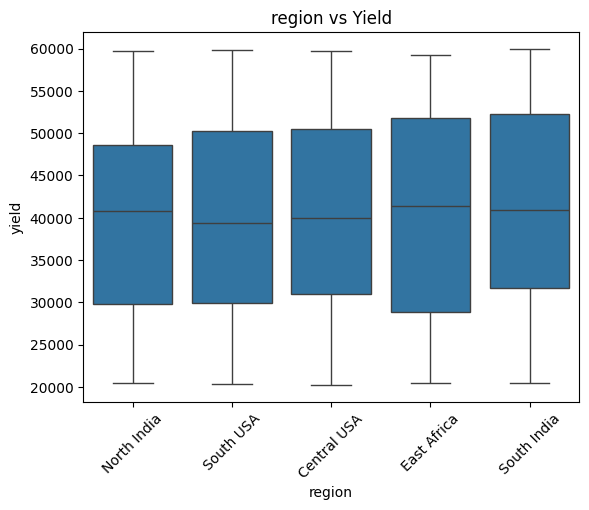

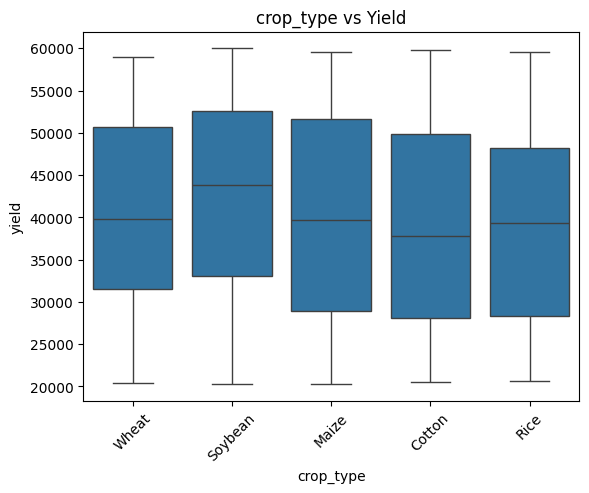

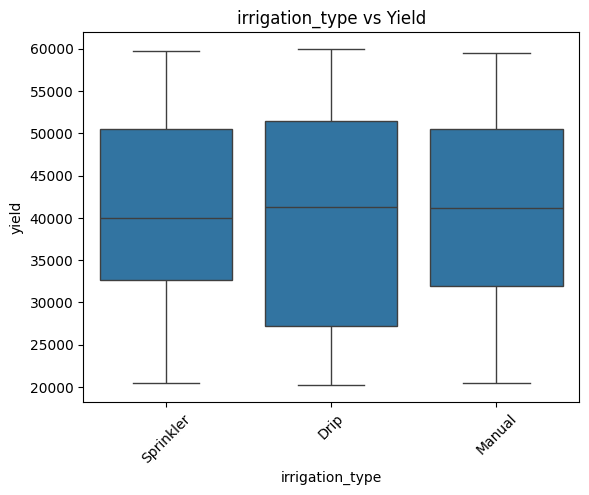

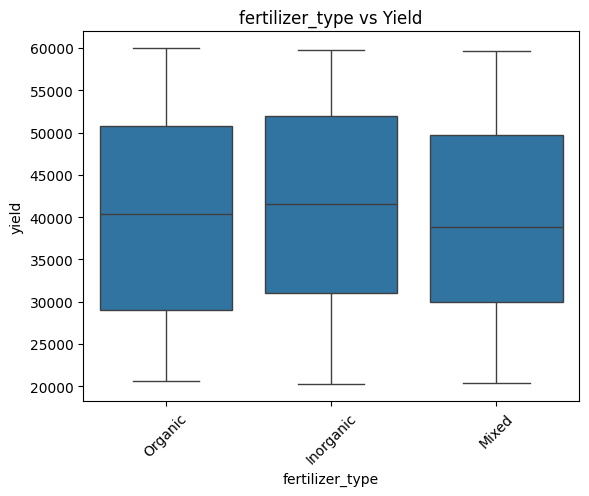

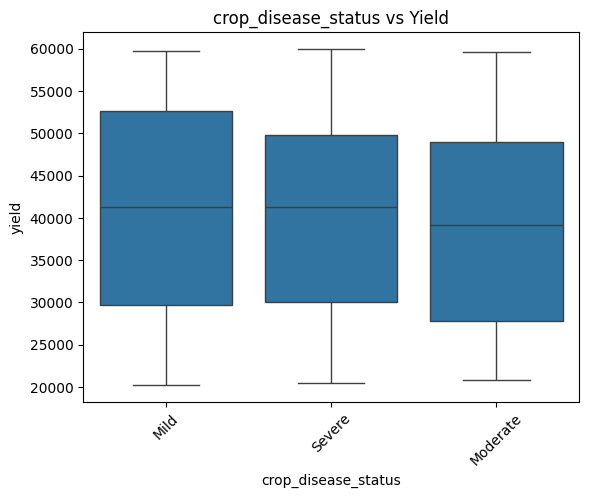

In [478]:
for col in ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']:
    plt.figure()
    sns.boxplot(x=df[col], y=df['yield'])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Yield")
    plt.show()

Jadi botplox ini digunakan untuk mengukur seberapa besar pengaruh suatu kolom ke target (yield). Kalau misalnya hasil dari botplox tida berbeda jauh satu sama lain, besar kemungkinan bahwa kolom tersebut tidak memiliki pengaruh yang signifikan atau jelas terhdapa distribusi yield. Contohnya seperti region, median dari region hampir sama satu sama lain hal ini berarti region tidak membawa pengaruh signifikan ke Yield. Tapi, ada juga yang lebih bervariasi dari botplox lainnya, yaitu crop_type.

In [479]:
for col in ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']:
    print(f"{col}:")
    print(df.groupby(col)['yield'].mean())
    print("-"*40)

region:
region
Central USA    40130.834862
East Africa    40531.844860
North India    39962.216162
South India    41228.846154
South USA      39844.488298
Name: yield, dtype: float64
----------------------------------------
crop_type:
crop_type
Cotton     39256.030841
Maize      39825.538739
Rice       38961.800000
Soybean    42568.140741
Wheat      40775.845652
Name: yield, dtype: float64
----------------------------------------
irrigation_type:
irrigation_type
Drip         40194.533333
Manual       40700.938983
Sprinkler    40844.119008
Name: yield, dtype: float64
----------------------------------------
fertilizer_type:
fertilizer_type
Inorganic    40871.228743
Mixed        39724.149701
Organic      40392.810241
Name: yield, dtype: float64
----------------------------------------
crop_disease_status:
crop_disease_status
Mild        40898.717600
Moderate    39159.153571
Severe      40293.442857
Name: yield, dtype: float64
----------------------------------------


Ini adalah tabel yang menunjukkan mean di setiap kategori. Bisa dilihat bahwa mean yang paling besar di tabel ini adalah Soybean dari kolom crop_type. Hal ini menunjukkan bahwa fitur crop_type memiliki pengaruh paling signifikan terhadap target (yield)

## Data Cleaning

#### Missing Value

In [480]:
df.isna().sum()

,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,1
irrigation_type,150
fertilizer_type,0


Heatmap membantu dalam mengidentifikasi apakah missing value muncul secara random atau terdapat patterns tertentu. Cara membaca heatmap ini adalah

hitam = data terisi

putih = data kosong

Bisa dilihat di bawah data yang hilang tidak mengikuti semua pola tertentu. Tapi untuk memastikan kedua kalinya, saya akan menggunakan mean dari masing-masing data yang kosong dan data yang terisi.

<Axes: >

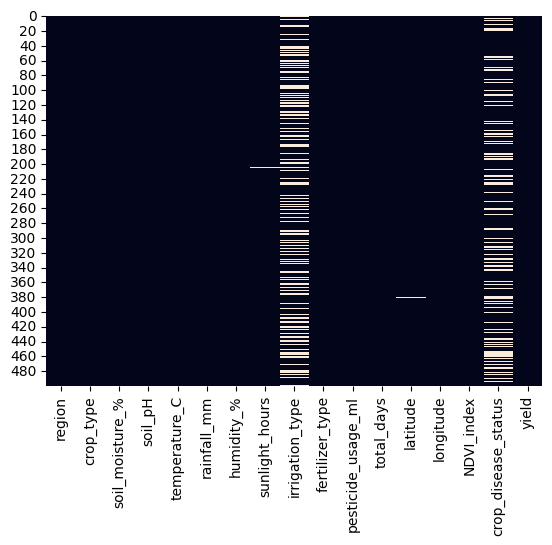

In [481]:
sns.heatmap(df.isnull(), cbar=False)

Jika mean hampir sama berarti missing value tidak memiliki pola tertentu. Dilihat dari kedua mean di bawah, bisa dikatakan bahwa missing value benar-benar tidak memiliki pola tertentu.

In [482]:
df[df['irrigation_type'].isnull()]['yield'].mean()
df[df['irrigation_type'].notnull()]['yield'].mean()

np.float64(40589.83542857143)

In [483]:
df[df['crop_disease_status'].isnull()]['yield'].mean()
df[df['crop_disease_status'].notnull()]['yield'].mean()

np.float64(40154.575135135135)

Untuk mengambil keputusan bagaimana missing value pada tiap kolom akan ditangani, saya akan melihat proporsi missing value dari data ini.

In [484]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Count,Percentage (%)
region,0,0.0
crop_type,0,0.0
soil_moisture_%,0,0.0
soil_pH,0,0.0
temperature_C,0,0.0
rainfall_mm,0,0.0
humidity_%,0,0.0
sunlight_hours,1,0.2
irrigation_type,150,30.0
fertilizer_type,0,0.0


kolom irrigation_type dan crop_disease_status memiliki persentase missing yang cukup tinggi karena mencapai angka 26% dan 30%. Karena dari research sebelumnya sudah ditentukan bahwa missing value ini tidak memiliki pola atau secara random, saya memutuskan untuk mengimpute kedua kolom ini menggunakan modus. Saya juga memutuskan untuk mengimpute sunlight hours dan latitude menggunakan mean karena tidak terlalu signifikan, dan jika didrop, saya akan kehilangan data penting yang berpengaruh pada target.

In [485]:
df['irrigation_type'] = df['irrigation_type'].fillna('Unknown')
df['crop_disease_status'] = df['crop_disease_status'].fillna('Unknown')

#### Duplicated checks

In [486]:
df.duplicated().sum()

np.int64(0)

#### Numerical Checks

In [487]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               500 non-null    object 
 1   crop_type            500 non-null    object 
 2   soil_moisture_%      500 non-null    float64
 3   soil_pH              500 non-null    float64
 4   temperature_C        500 non-null    float64
 5   rainfall_mm          500 non-null    float64
 6   humidity_%           500 non-null    float64
 7   sunlight_hours       499 non-null    float64
 8   irrigation_type      500 non-null    object 
 9   fertilizer_type      500 non-null    object 
 10  pesticide_usage_ml   500 non-null    float64
 11  total_days           500 non-null    int64  
 12  latitude             498 non-null    float64
 13  longitude            500 non-null    float64
 14  NDVI_index           500 non-null    float64
 15  crop_disease_status  500 non-null    obj

##### distribusi numerik overview dengan histogram

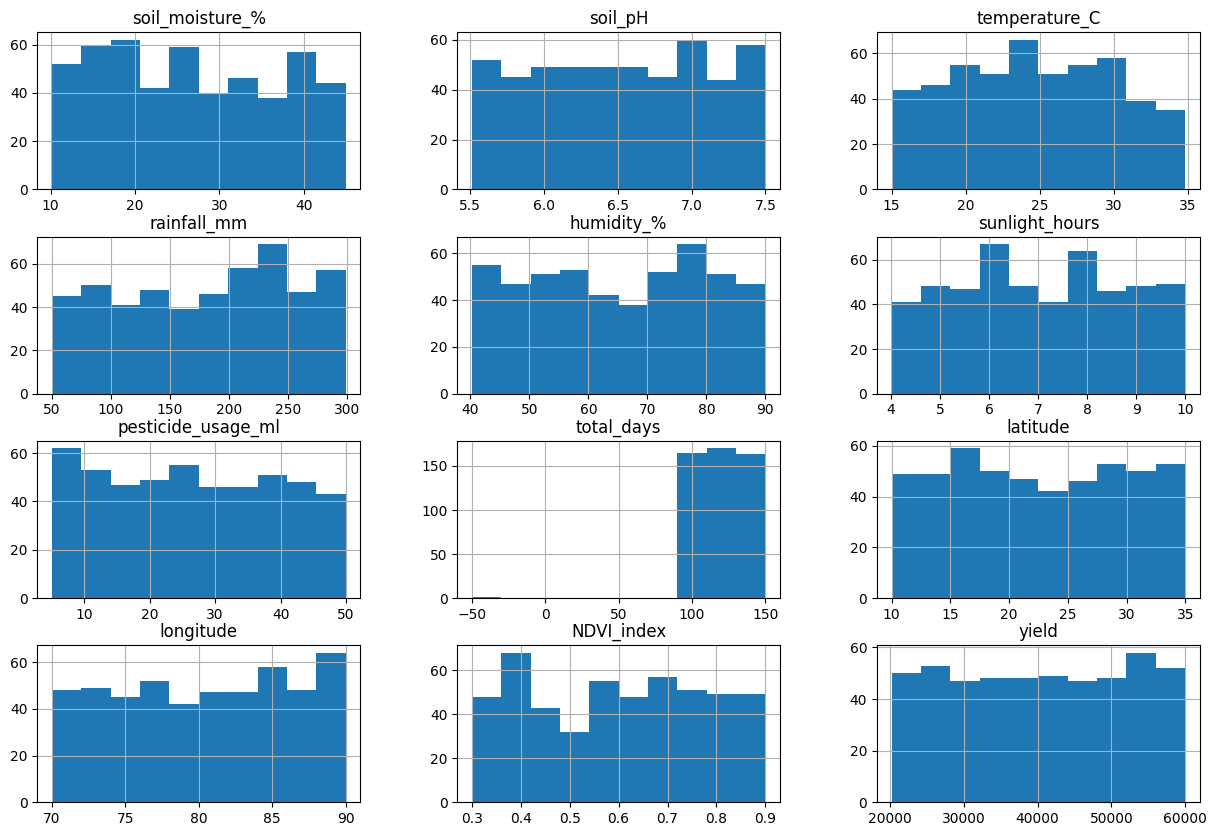

In [488]:
df.hist(figsize=(15,10))
plt.show()

Beberapa fitur memang memiliki sifat yang skew sedikit contohnya seperti temperatur, NDVI index, sunlight hours. Fitur total_days juga tidak variatif, hal ini mungkin dikarenakan karena adanya outlier di titik -50

In [489]:
df['sunlight_hours'] = df['sunlight_hours'].fillna(df['sunlight_hours'].mean())
df['latitude'] = df['latitude'].fillna(df['latitude'].mean())

##### outlier checks dengan boxplot

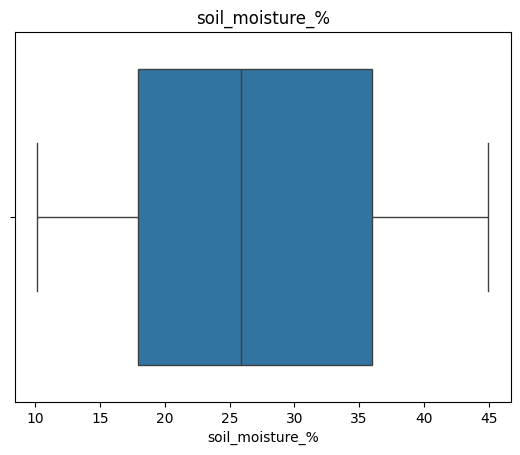

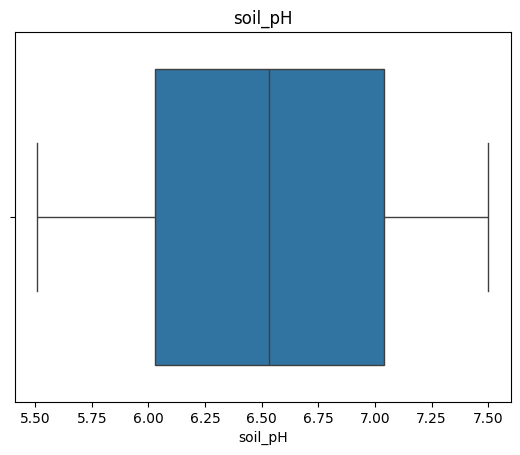

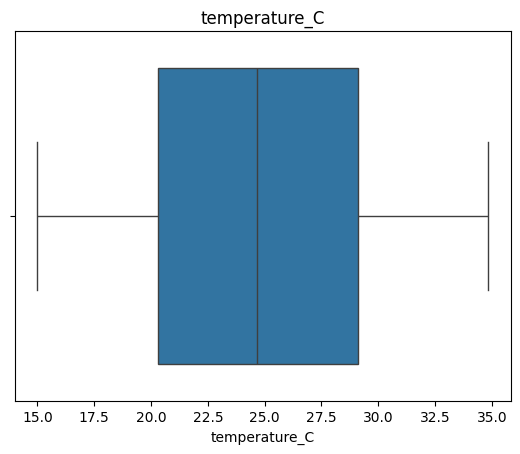

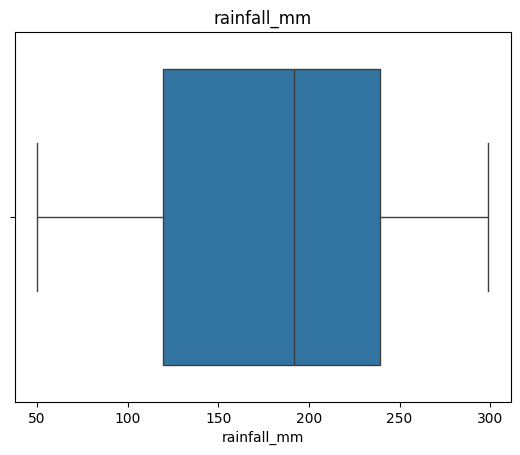

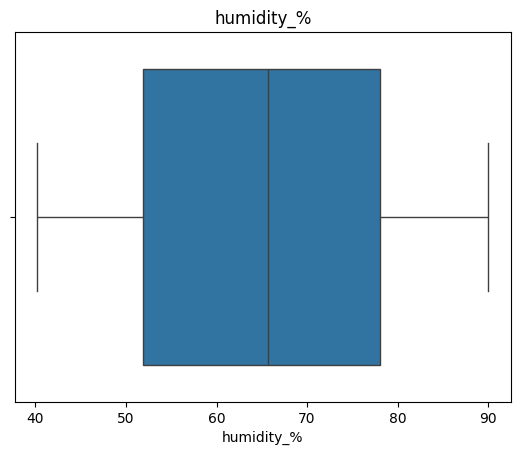

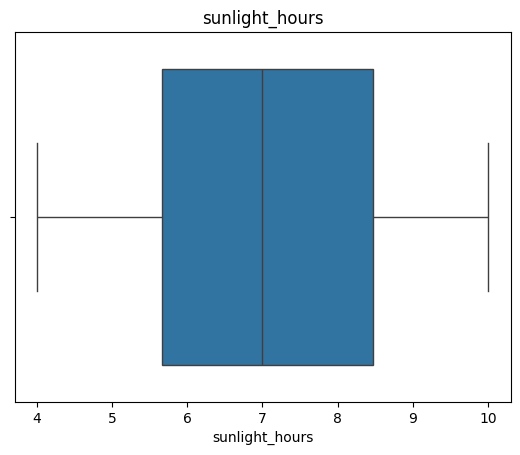

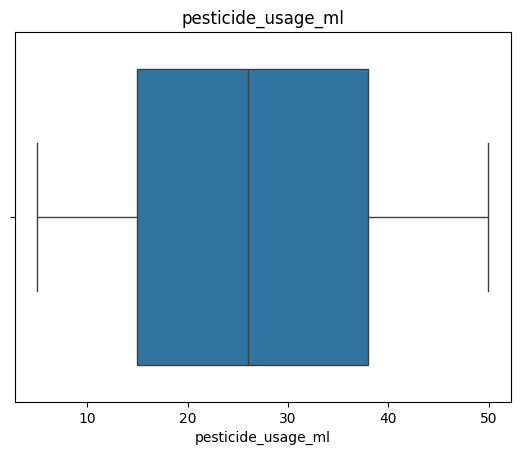

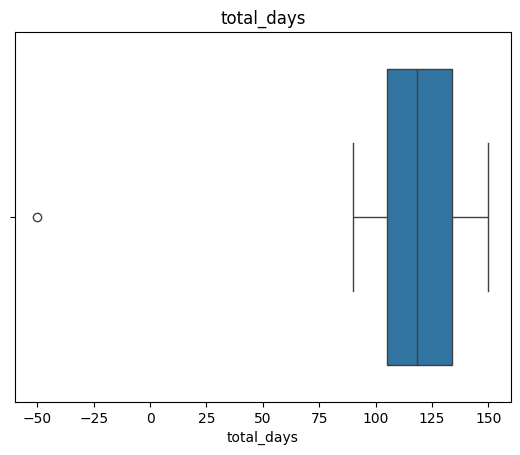

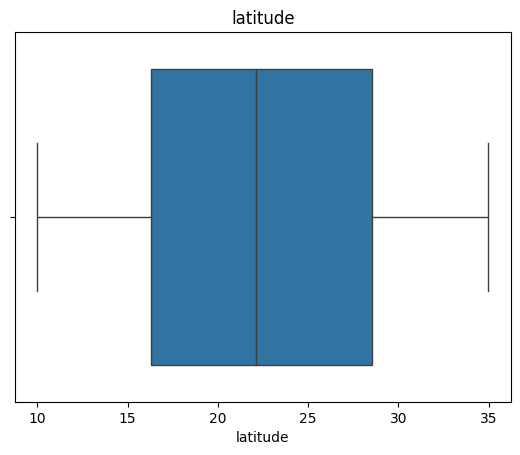

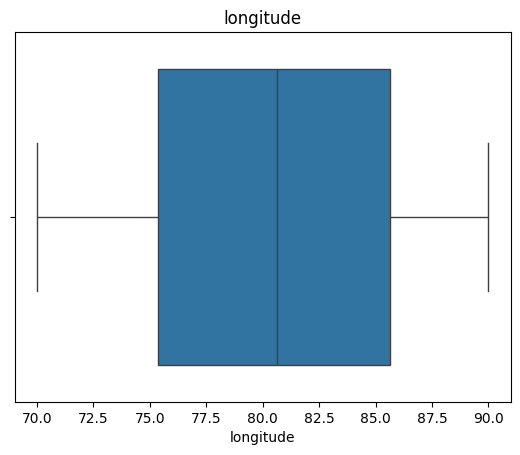

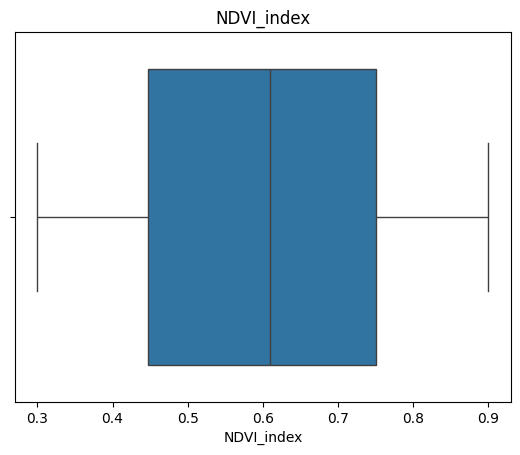

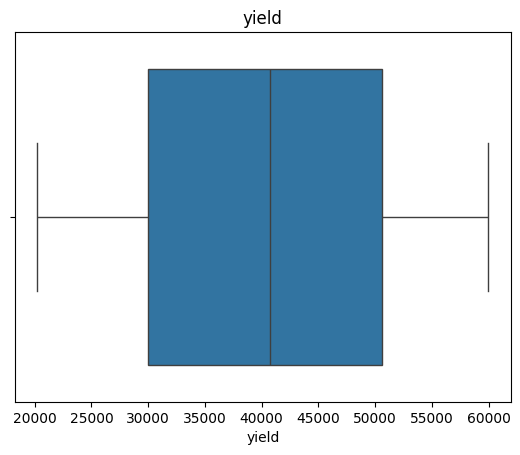

In [490]:
for col in df.select_dtypes(include='number'):
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [491]:
num_df = df.select_dtypes(include='number')

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))

outlier_count = outlier_mask.sum()

print(outlier_count)

soil_moisture_%       0
soil_pH               0
temperature_C         0
rainfall_mm           0
humidity_%            0
sunlight_hours        0
pesticide_usage_ml    0
total_days            1
latitude              0
longitude             0
NDVI_index            0
yield                 0
dtype: int64


Dari boxplot diatas, banyak data yang tidak memiliki outlier dan cenderung stabil. Tapi anomali yang paling terlihat ada di total_days karena ada titik yang berada di sisi kiri negatif. Hal ini aneh karena tidak mungkin terjadi secara logika. Hal ini disebut invalid value karena tidak masuk akal. Saya akan melakukan imputasi terhadap data anomali tersebut.

In [492]:
(df['total_days'] < 0).sum()

np.int64(1)

Karena hanya ada 1 data yang di bawah nilai 0 (invalid value) saya akan melakukan imputasi menggunakan mean dari total days.

In [493]:
df.loc[df['total_days'] < 0, 'total_days'] = np.nan
df['total_days'].fillna(df['total_days'].mean(), inplace=True)

/tmp/ipykernel_8830/227963881.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_days'].fillna(df['total_days'].mean(), inplace=True)


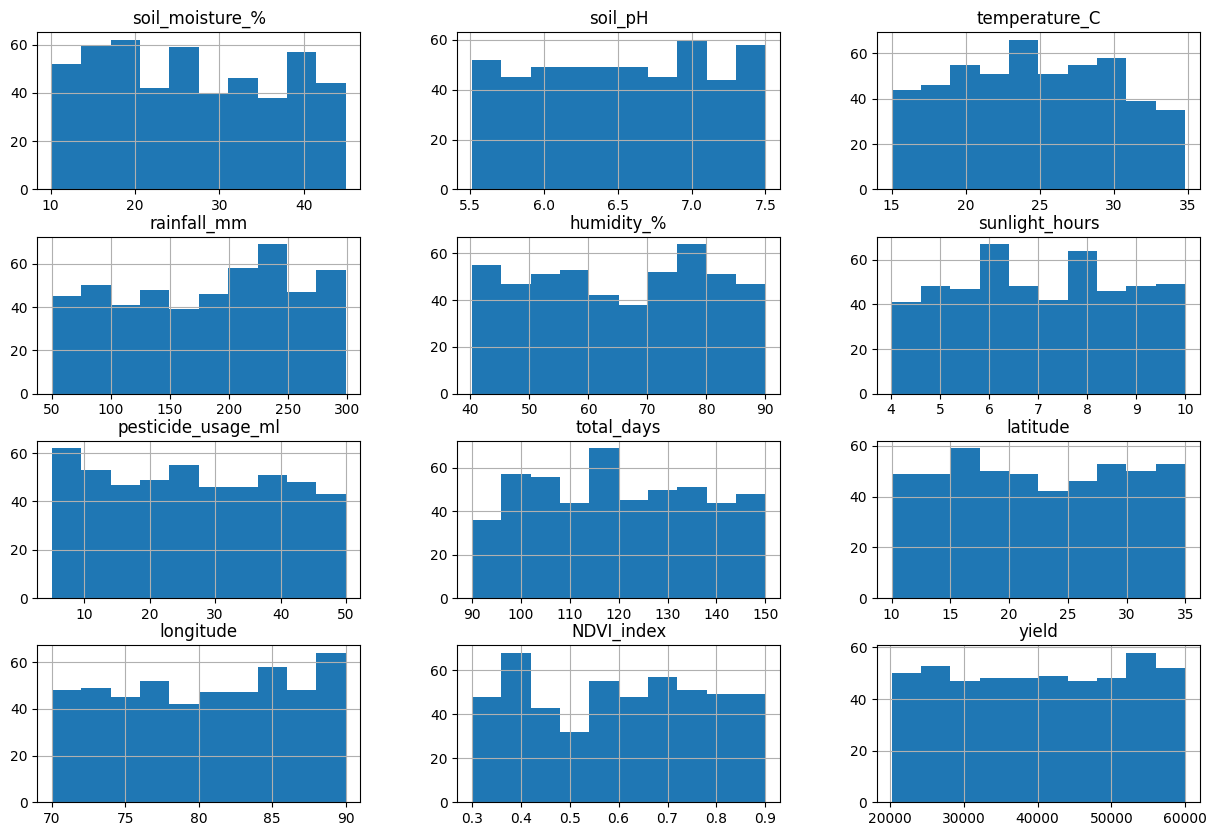

In [494]:
df.hist(figsize=(15,10))
plt.show()

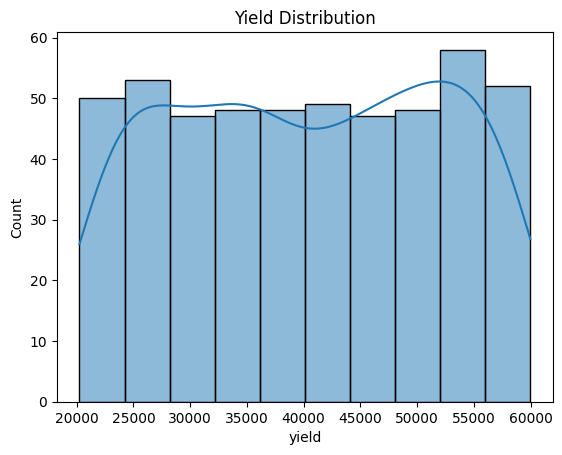

In [495]:
sns.histplot(df['yield'], kde=True)
plt.title("Yield Distribution")
plt.show()

Distribusi variabel target menunjukkan bahwa pola yang merata dan tidak ada skew yang signifikan.

#### Correlation Checks

##### Heatmap

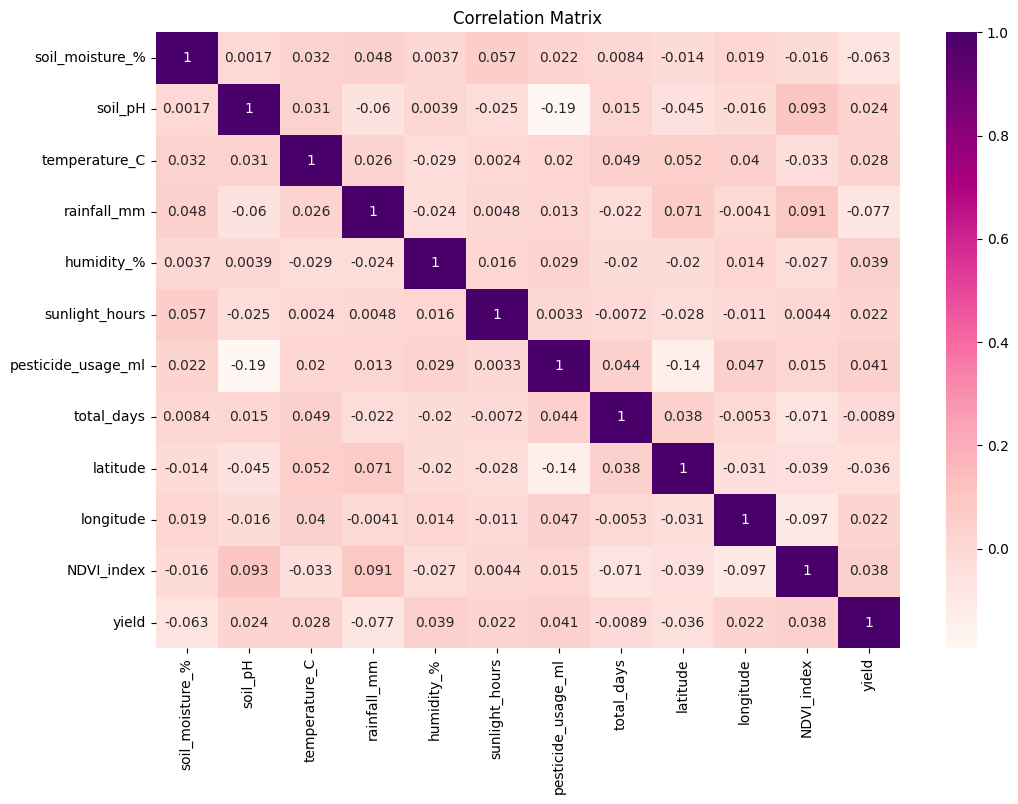

In [496]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdPu')
plt.title("Correlation Matrix")
plt.show()

Dari heatmap terlihat bahwa tidak ada fitur yang memiliki hubungan yang kuat secara langsung dengan yield. Hal ini menunjukkan bahwa hasil panen kemungkinan dipengaruhi oleh kombinasi banyak faktor, bukan hanya satu variabel saja. Hal ini akab berakibat kepada hasil model, contohnya seperti resiko overfitting.

##### Kategorikal dengan P-Value / ANOVA

In [497]:
from scipy.stats import f_oneway

cat_cols = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']

for col in cat_cols:
    groups = [df[df[col] == c]['yield'] for c in df[col].unique()]
    stat, p = f_oneway(*groups)

    print(f"{col}: p-value = {p}")

region: p-value = 0.9317175605186352
crop_type: p-value = 0.17993224645996467
irrigation_type: p-value = 0.8580415801912717
fertilizer_type: p-value = 0.6698997173373573
crop_disease_status: p-value = 0.6516231205071019


p-value<0.05 artinya signifikan

p-value > 0.05 tidak signifikan

dari nilai-nilai p-value yang sudah didapatkan diatas, dapat dikatakan bahwa satu variabel saja tidak cukup untuk menunjukkan hubungan yang kuat dengan target (Yield)

##### Numerikal dengan Pearson

In [498]:
df.corr(numeric_only=True)['yield']

,yield
soil_moisture_%,-0.063038
soil_pH,0.024274
temperature_C,0.027875
rainfall_mm,-0.076802
humidity_%,0.039021
sunlight_hours,0.021559
pesticide_usage_ml,0.041290
total_days,-0.008916
latitude,-0.035769
longitude,0.022359


Makin mendekati 1 makin KUAT. Interretasi fitur numerik juga tidak jauh berbeda dengan fitur kategorikal. Tidak ada fitur yang punya hubungan cukup kuat dengan hasil panen atau yield (target). Kesimpulannya, dari semua correlation checks yang sudah dilakukan, tidak ada fitur yang secara langsung memiliki hubungan kuat dengan target. Maka dari itu, ANN dipilih dalam kasus ini.

In [499]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               500 non-null    object 
 1   crop_type            500 non-null    object 
 2   soil_moisture_%      500 non-null    float64
 3   soil_pH              500 non-null    float64
 4   temperature_C        500 non-null    float64
 5   rainfall_mm          500 non-null    float64
 6   humidity_%           500 non-null    float64
 7   sunlight_hours       500 non-null    float64
 8   irrigation_type      500 non-null    object 
 9   fertilizer_type      500 non-null    object 
 10  pesticide_usage_ml   500 non-null    float64
 11  total_days           500 non-null    float64
 12  latitude             500 non-null    float64
 13  longitude            500 non-null    float64
 14  NDVI_index           500 non-null    float64
 15  crop_disease_status  500 non-null    obj

In [500]:
df.head()

,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,crop_disease_status,yield
0,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,Unknown,Organic,6.34,122.0,14.970941,82.997689,0.63,Mild,44080.7
1,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,Inorganic,9.60,112.0,16.613022,70.869009,0.58,Unknown,53899.8
2,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,Mixed,15.26,144.0,19.503156,79.068206,0.80,Mild,29311.6
3,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,Organic,25.80,134.0,31.071298,85.519998,0.44,Unknown,42278.0
4,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,Unknown,Mixed,25.65,105.0,16.568540,81.691720,0.84,Severe,49799.6


In [501]:
df.columns

Index(['region', 'crop_type', 'soil_moisture_%', 'soil_pH', 'temperature_C',
       'rainfall_mm', 'humidity_%', 'sunlight_hours', 'irrigation_type',
       'fertilizer_type', 'pesticide_usage_ml', 'total_days', 'latitude',
       'longitude', 'NDVI_index', 'crop_disease_status', 'yield'],
      dtype='object')

#### Feature Engineering

Dengan menggabungkan beberapa variabel, saya harap model dapat lebih mudah memahami pola yang berpengaruh terhadap nilai yield, terutama karena dari analisis sebelumnya hubungan antar fitur terlihat cukup lemah.

temp humidity menggabungkan suhu dan kelembaban, karena kedua faktor ini saling berkaitan dalam mempengaruhi kondisi pertumbuhan tanaman.

growth_index : NDVI menunjukkan tingkat kesehatan tanaman, sedangkan durasi sinar matahari mempengaruhi proses fotosintesis. Tanaman yang sehat dan mendapat cukup sinar matahari cenderung menghasilkan yield yang lebih tinggi.

rain_sun untuk perbandingan jumlah hujan. Hal ini penting karena keseimbangan keduanya mempengaruhi pertumbuhan tanaman.


In [502]:
df['temp_humidity'] = df['temperature_C'] * df['humidity_%']
df['growth_index'] = df['NDVI_index'] * df['sunlight_hours']
df['rain_sun'] = df['rainfall_mm'] / (df['sunlight_hours'] + 1)

#### Splitting 70:10:20

In [503]:
X = df.drop('yield', axis=1)
y = df['yield']

In [504]:
# split test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# split val 10% dari train
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42
)

# cek ukuran
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(350, 19) (350,)
(50, 19) (50,)
(100, 19) (100,)


### Encoding

Saya melakukan One Hot Encoder karena tidakada fitur yang memiliki tipe ordinal atau berurutan, semua fitur tidak memiliki urutan di kategorinya. Jadi saya memilih untuk menggunakan encoding dengan OneHotEncoder

In [505]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include='number').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

X_train_final = preprocessor.fit_transform(X_train)
X_val_final = preprocessor.transform(X_val)
X_test_final = preprocessor.transform(X_test)

In [506]:
X_train_final.shape

(350, 30)

In [507]:
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val = scaler_y.transform(y_val.values.reshape(-1,1))
y_test = scaler_y.transform(y_test.values.reshape(-1,1))

# Build Model Baseline

In [508]:
from tensorflow import keras
from tensorflow.keras import layers

In [509]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Jumlah neuron sebesar 64 dipilih karena memenuhi ketentuan minimal dua kali jumlah fitur input (≥50), sekaligus menjaga keseimbangan antara kapasitas model dan risiko overfitting.

## early stopping

In [510]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [511]:
print(X_train_final.shape)

(350, 30)


## Compile dan Training

In [512]:
model_baseline = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(),
        keras.metrics.RootMeanSquaredError()
    ]
)

In [513]:
history_baseline = model_baseline.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - loss: 1.0885 - mean_absolute_error: 0.8798 - root_mean_squared_error: 1.0433 - val_loss: 1.0408 - val_mean_absolute_error: 0.8956 - val_root_mean_squared_error: 1.0202
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.9933 - mean_absolute_error: 0.8513 - root_mean_squared_error: 0.9967 - val_loss: 1.0219 - val_mean_absolute_error: 0.8912 - val_root_mean_squared_error: 1.0109
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.9279 - mean_absolute_error: 0.8259 - root_mean_squared_error: 0.9633 - val_loss: 0.9997 - val_mean_absolute_error: 0.8809 - val_root_mean_squared_error: 0.9998
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.8898 - mean_absolute_error: 0.8088 - root_mean_squared_error: 0.9433 - val_loss: 0.9813 - val_mean_absolute_error: 0.8723 - val_root_mean_squared_error: 0.9906
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.8516 - mean_absolute_error: 0.7914 - root_mean_squared

## Kesimpulan
Disini model dilatih selama beberapa EPOCH dan menunjukkan penurunan nilai LOSS yang membuktikan kalau model memang mempelajari pola data training semakin baik.

Tapi jika dilihat dari validation loss, model tidak menunjukkan performa yang konsisten. Validation loss mengalami penurunan pada beberapa epoch awal, kemudian meningkat seiring bertambahnya epoch. Hal ini menandakan bahwa model mulai mengalami overfitting, dimana model terlalu menyesuaikan diri terhadap data training dan tidak mampu melakukan generalisasi dengan baik pada data yang belum pernah dilihat.

dapat disimpulkan bahwa model baseline memiliki kecenderungan untuk menghafal data training dibandingkan memahami pola yang sebenarnya.

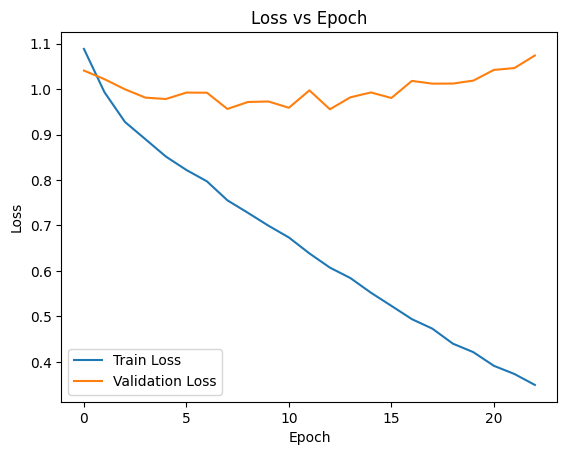

In [514]:
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Grafik ini juga menunjukkan hal yang sama, bahwa train loss memang menjadi lebih baik tapi validation loss terus naik-turun dan kondisi paling baik model adalah pada saat epoch ke 2-3 tapi naik lagi.


Dari hasil analisis data dan pembuatan model, dapat disimpulkan bahwa tidak ada satu faktor pun yang secara jelas dan langsung menentukan hasil panen. Sebagian besar variabel seperti cuaca, jenis tanaman, atau metode irigasi tidak menunjukkan hubungan yang kuat jika dilihat secara terpisah.


Hal ini menunjukkan bahwa hasil panen kemungkinan dipengaruhi oleh banyak faktor secara bersamaan, bukan hanya satu atau dua faktor saja. Model cenderung menghafal data yang sudah ada, tetapi belum benar-benar memahami pola yang bisa digunakan untuk memprediksi data baru.

# 1B. Tuning Model
Setelah saya mencoba rangkaian model, akhirnya model ini dipilih karena memberikan hasil yang paling stabil dibandingkan model lain.

Model tuned menggunakan arsitektur yang lebih kompleks dibandingkan baseline, dengan menambah jumlah neuron menjadi 128, 64, dan 32. Tujuannya supaya model bisa menangkap pola yang lebih kompleks dari data. Bentuk layer yang makin kecil ke bawah membantu model menyaring informasi secara bertahap.

Selain itu, batch size dibuat lebih kecil agar proses belajar lebih stabil dan hasilnya bisa lebih general (tidak hanya bagus di data training). Early stopping juga digunakan supaya training berhenti saat model mulai overfitting.

Regularisasi seperti dropout tidak digunakan karena ingin memberi model ruang lebih untuk belajar pola dari data tanpa terlalu dibatasi.

In [515]:
model_tuned = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_tuned.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(),
        keras.metrics.RootMeanSquaredError()
    ]
)

history_tuned = model_tuned.fit(
    X_train_final, y_train,
    validation_data=(X_val_final, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 1.0359 - mean_absolute_error: 0.8839 - root_mean_squared_error: 1.0178 - val_loss: 0.9353 - val_mean_absolute_error: 0.8352 - val_root_mean_squared_error: 0.9671
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8906 - mean_absolute_error: 0.8207 - root_mean_squared_error: 0.9437 - val_loss: 0.9398 - val_mean_absolute_error: 0.8451 - val_root_mean_squared_error: 0.9694
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.8029 - mean_absolute_error: 0.7764 - root_mean_squared_error: 0.8960 - val_loss: 0.9031 - val_mean_absolute_error: 0.8347 - val_root_mean_squared_error: 0.9503
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.7209 - mean_absolute_error: 0.7298 - root_mean_squared_error: 0.8491 - val_loss: 0.9140 - val_mean_absolute_error: 0.8341 - val_root_mean_squared_error: 0.9561
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6396 - mean_absolute_error: 0.6783 - root_mean_squ

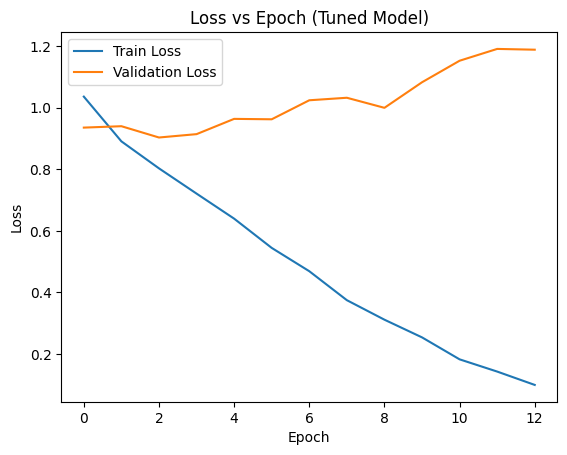

In [516]:
plt.figure()

plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title('Loss vs Epoch (Tuned Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

Berdasarkan grafik loss, model menunjukkan performa yang masih baik hingga sekitar epoch ke-2 sampai ke-3, di mana training loss dan validation loss sama-sama mengalami penurunan. Namun setelah itu, validation loss mulai meningkat sementara training loss terus menurun. Hal ini menunjukkan bahwa model mulai mengalami overfitting sejak sekitar epoch ke-3 hingga ke-4, di mana model terlalu menyesuaikan diri dengan data training dan kehilangan kemampuan generalisasi terhadap data validasi.


Meskipun model telah dilakukan tuning dengan menambah jumlah layer dan neuron, hasil yang diperoleh masih belum menunjukkan peningkatan yang signifikan dibandingkan baseline. Hal ini dapat disebabkan oleh

# 1C

In [517]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_base_scaled = model_baseline.predict(X_val_final)

y_pred_base = scaler_y.inverse_transform(y_pred_base_scaled)
y_val_orig = scaler_y.inverse_transform(y_val)

y_pred_tuned_scaled = model_tuned.predict(X_val_final)

y_pred_tuned = scaler_y.inverse_transform(y_pred_tuned_scaled)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

mae_base, mse_base, rmse_base, r2_base = evaluate(y_val_orig, y_pred_base)
mae_tuned, mse_tuned, rmse_tuned, r2_tuned = evaluate(y_val_orig, y_pred_tuned)

results = pd.DataFrame({
    'Model': ['Baseline', 'Tuned'],
    'MAE': [mae_base, mae_tuned],
    'MSE': [mse_base, mse_tuned],
    'RMSE': [rmse_base, rmse_tuned],
    'R2': [r2_base, r2_tuned]
})

print(results)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
      Model           MAE           MSE          RMSE        R2
0  Baseline  10016.715023  1.318380e+08  11482.071522 -0.038460
1     Tuned   9804.081398  1.245882e+08  11161.910493  0.018645


1. MAE pada model tuned lebih kecil dibandingkan baseline, yang berarti rata-rata error prediksi menjadi lebih kecil. Dengan kata lain, hasil prediksi model tuned lebih mendekati nilai sebenarnya.

2. Nilai MSE juga menurun pada model tuned. Ini menunjukkan bahwa outlier errorberhasil sedikit dikurangi dibandingkan model baseline.

3. RMSE pada model tuned lebih rendah, yang berarti secara keseluruhan tingkat error model lebih kecil dalam skala asli data. Hal ini menguatkan bahwa model tuned sedikit lebih akurat.

4. Nilai R² meningkat dari negatif menjadi positif. Artinya, model tuned sudah mulai bisa menangkap pola dalam data, meskipun kemampuannya masih sangat terbatas.

## Kesimpulan

Saya membuat dua model, yaitu baseline dan tuned. Model baseline terlihat bagus di data training, tetapi kurang baik saat diuji ke data baru, yang menunjukkan adanya overfitting.

Model tuned dibuat dengan arsitektur yang lebih kompleks dan hasilnya sedikit lebih baik, terlihat dari error yang lebih kecil dan nilai R² yang meningkat. Namun, dari grafik validation loss, model ini masih mengalami overfitting karena performanya tidak stabil pada data validasi.

Jadi, meskipun model tuned lebih baik dari baseline, hasilnya masih belum optimal. Hal ini kemungkinan karena fitur yang digunakan belum memiliki hubungan yang kuat dengan target, sehingga model sulit belajar dengan baik.